In [3]:
import sys
!{sys.executable} -m pip install textblob
import textblob
print("✅ TextBlob is now installed!")

✅ TextBlob is now installed!



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the scripts folder is visible
sys.path.append(os.path.abspath('../'))
from scripts.data_loader import DataLoader
from scripts.analyzer import FinancialAnalyzer

# Initialize Task 1 data
loader = DataLoader('../data/raw_analyst_ratings.csv')
df = loader.load_data()
df = loader.clean_data()

✅ Loaded 1407328 rows.
✅ Data cleaned and self.df updated.


In [6]:
# We use a sample of 100k if 1.4M is too slow for your PC, 
print("Analyzing sentiment... please wait.")
df['sentiment_score'] = df['headline'].apply(FinancialAnalyzer.get_sentiment)
df['sentiment_label'] = df['sentiment_score'].apply(FinancialAnalyzer.categorize_sentiment)

print("✅ Analysis Complete.")
print(df[['headline', 'sentiment_score', 'sentiment_label']].head())

Analyzing sentiment... please wait.
✅ Analysis Complete.
                                            headline  sentiment_score  \
0            Stocks That Hit 52-Week Highs On Friday              0.0   
1         Stocks That Hit 52-Week Highs On Wednesday              0.0   
2                      71 Biggest Movers From Friday              0.0   
3       46 Stocks Moving In Friday's Mid-Day Session              0.0   
4  B of A Securities Maintains Neutral on Agilent...              0.0   

  sentiment_label  
0         Neutral  
1         Neutral  
2         Neutral  
3         Neutral  
4         Neutral  


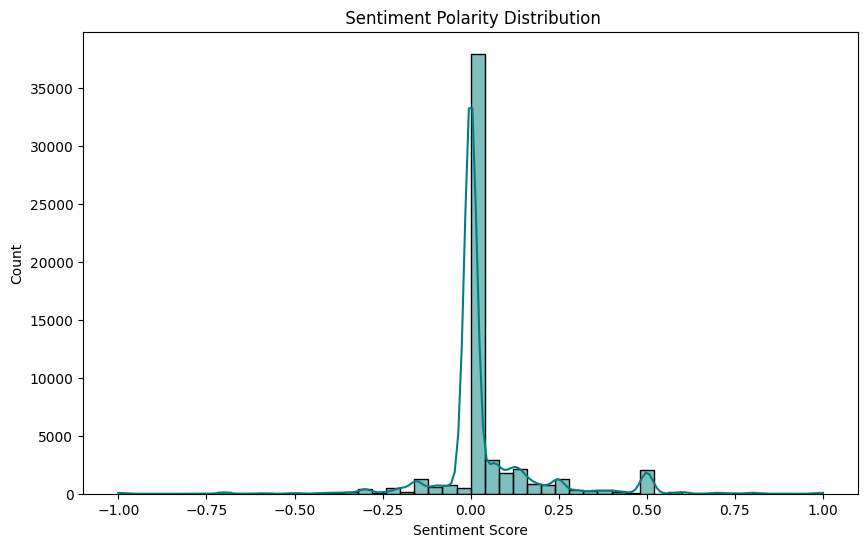

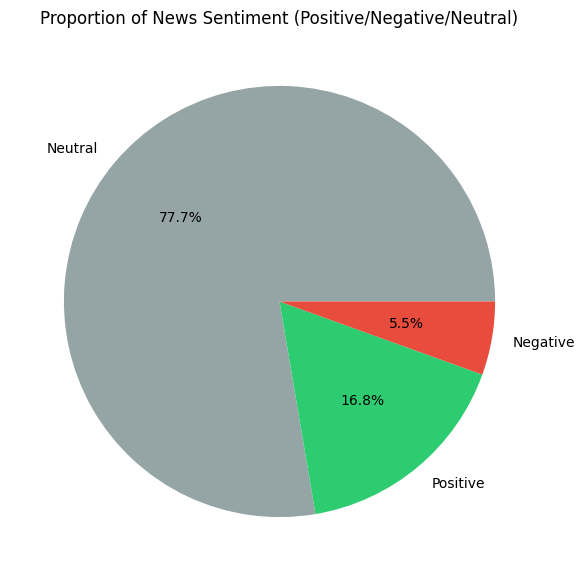

In [8]:
# Visualization 1: Distribution of Sentiment
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=50, kde=True, color='teal')
plt.title(" Sentiment Polarity Distribution")
plt.xlabel("Sentiment Score")
plt.show()

# Visualization 2: Sentiment Labels
plt.figure(figsize=(7, 7))
df['sentiment_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71', '#e74c3c'])
plt.title("Proportion of News Sentiment (Positive/Negative/Neutral)")
plt.ylabel("")
plt.show()